<a href="https://colab.research.google.com/github/VoRtExxs/Final-Project-trojan-detector/blob/main/Phase3_ML_Pipeline_ASD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# PHASE 3 — ASD Early Detection ML Pipeline
# Experiment 1: Full Dataset (n=1,054)
# Models: SVM + Logistic Regression
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             ConfusionMatrixDisplay)
import shap
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
# Load your clean file
df = pd.read_csv('ASD_Toddler_Clean.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nTarget distribution:")
print(df['Class/ASD Traits'].value_counts(normalize=True).round(3))

Dataset shape: (1054, 30)

Column names:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Sex', 'Jaundice', 'Family_mem_with_ASD', 'Class/ASD Traits', 'Ethnicity_Asian', 'Ethnicity_Black', 'Ethnicity_Hispanic', 'Ethnicity_Latino', 'Ethnicity_Middle Eastern', 'Ethnicity_Mixed', 'Ethnicity_Native Indian', 'Ethnicity_Others', 'Ethnicity_Pacifica', 'Ethnicity_South Asian', 'Ethnicity_White European', 'Who completed the test_Family Member', 'Who completed the test_Health Care Professional', 'Who completed the test_Others', 'Who completed the test_Self']

Target distribution:
Class/ASD Traits
1    0.691
0    0.309
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# ENCODING
# The One-Hot columns (Ethnicity, Who completed) are preprocessed
# We just need to see if Sex, Jaundice, Family_mem_with_ASD
# And Class/ASD Traits are still textual or numerical
# ============================================================

df_encoded = df.copy()

#Check the type of these columns first
cols_to_check = ['Sex', 'Jaundice', 'Family_mem_with_ASD', 'Class/ASD Traits']

for col in cols_to_check:
    print(f"{col}: dtype={df_encoded[col].dtype}, values={df_encoded[col].unique()}")

Sex: dtype=int64, values=[0 1]
Jaundice: dtype=int64, values=[1 0]
Family_mem_with_ASD: dtype=int64, values=[0 1]
Class/ASD Traits: dtype=int64, values=[0 1]


In [ ]:
# ============================================================
# FEATURE / TARGET SPLIT
# X = all columns except the target
# y =  target (0 = No ASD, 1 = ASD)
# ============================================================

TARGET = 'Class/ASD Traits'

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f"Features (X): {X.shape[1]} columns, {X.shape[0]} rows")
print(f"Target (y): {y.value_counts().to_dict()}")
print(f"\nFeature list:\n{X.columns.tolist()}")

Features (X): 29 columns, 1054 rows
Target (y): {1: 728, 0: 326}

Feature list:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Sex', 'Jaundice', 'Family_mem_with_ASD', 'Ethnicity_Asian', 'Ethnicity_Black', 'Ethnicity_Hispanic', 'Ethnicity_Latino', 'Ethnicity_Middle Eastern', 'Ethnicity_Mixed', 'Ethnicity_Native Indian', 'Ethnicity_Others', 'Ethnicity_Pacifica', 'Ethnicity_South Asian', 'Ethnicity_White European', 'Who completed the test_Family Member', 'Who completed the test_Health Care Professional', 'Who completed the test_Others', 'Who completed the test_Self']


In [ ]:
# ============================================================
# STRATIFIED SPLIT — 80/20
# stratify=y ensures that the 69/31 ratio is preserved in Train and Test
# Without it: The test could be 90% ASD by chance → misleading results
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class distribution:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set : 843 samples
Test set     : 211 samples

Train class distribution:
Class/ASD Traits
1    0.69
0    0.31
Name: proportion, dtype: float64

Test class distribution:
Class/ASD Traits
1    0.692
0    0.308
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# FEATURE SCALING (StandardScaler)
# fit_transform على Train فقط
# transform فقط على Test — ممنوع fit هنا
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# نرجّعها DataFrame للحفاظ على أسماء الأعمدة (مهم لـ SHAP لاحقاً)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("✅ Scaling complete")
print(f"Train mean (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std().mean():.4f}")
print(f"\nAge_Mons before scaling - min: {X_train['Age_Mons'].min()}, max: {X_train['Age_Mons'].max()}")
print(f"Age_Mons after scaling  - min: {X_train_scaled['Age_Mons'].min():.3f}, max: {X_train_scaled['Age_Mons'].max():.3f}")

✅ Scaling complete
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0006

Age_Mons before scaling - min: 12, max: 36
Age_Mons after scaling  - min: -1.987, max: 1.025


In [ ]:
# ============================================================
# BASELINE SVM
# kernel='rbf'        : الأكثر شيوعاً للداتا الجدولية
# class_weight='balanced' : يعوّض عن الـ 69/31 imbalance
# probability=True    : مطلوب لحساب AUC-ROC لاحقاً
# ============================================================

svm_baseline = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

svm_baseline.fit(X_train_scaled, y_train)
y_pred_svm_base = svm_baseline.predict(X_test_scaled)
y_prob_svm_base = svm_baseline.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("BASELINE SVM — Experiment 1 (Full Dataset)")
print("=" * 50)
print(classification_report(y_test, y_pred_svm_base,
                             target_names=['No ASD (0)', 'ASD (1)']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_svm_base):.4f}")
print(f"F1(ASD) : {f1_score(y_test, y_pred_svm_base):.4f}")

BASELINE SVM — Experiment 1 (Full Dataset)
              precision    recall  f1-score   support

  No ASD (0)       0.94      0.95      0.95        65
     ASD (1)       0.98      0.97      0.98       146

    accuracy                           0.97       211
   macro avg       0.96      0.96      0.96       211
weighted avg       0.97      0.97      0.97       211

AUC-ROC : 0.9948
F1(ASD) : 0.9759


In [ ]:
# ============================================================
# BASELINE LOGISTIC REGRESSION
# نفس المبدأ — بدون tuning
# max_iter=1000 : يضمن وصول الخوارزمية للحل
# ============================================================

lr_baseline = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_base = lr_baseline.predict(X_test_scaled)
y_prob_lr_base = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("=" * 50)
print("BASELINE LOGISTIC REGRESSION — Experiment 1")
print("=" * 50)
print(classification_report(y_test, y_pred_lr_base,
                             target_names=['No ASD (0)', 'ASD (1)']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_prob_lr_base):.4f}")
print(f"F1(ASD) : {f1_score(y_test, y_pred_lr_base):.4f}")

BASELINE LOGISTIC REGRESSION — Experiment 1
              precision    recall  f1-score   support

  No ASD (0)       1.00      1.00      1.00        65
     ASD (1)       1.00      1.00      1.00       146

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211

AUC-ROC : 1.0000
F1(ASD) : 1.0000


In [ ]:
# نتحقق من الـ coefficients — أيّ عمود يهيمن؟
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_baseline.coef_[0]
}).reindex(columns=['Feature', 'Coefficient'])

coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print(coef_df.head(10).to_string(index=False))

Feature  Coefficient  Abs_Coef
     A2     2.237060  2.237060
     A9     2.191300  2.191300
     A8     2.027981  2.027981
    A10     1.939963  1.939963
     A5     1.939214  1.939214
     A4     1.939165  1.939165
     A6     1.920060  1.920060
     A7     1.910677  1.910677
     A1     1.830643  1.830643
     A3     1.784823  1.784823


In [ ]:
# ============================================================
# SVM HYPERPARAMETER TUNING
# C     : كم نعاقب الموديل على الأخطاء
#         صغير = يتسامح | كبير = يحاول يصيب كل شي
# gamma : مدى تأثير كل نقطة تدريب
# kernel: rbf للأنماط غير الخطية، linear للأنماط البسيطة
# ============================================================

svm_param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_grid = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train_scaled, y_train)

print(f"\n✅ Best SVM Parameters : {svm_grid.best_params_}")
print(f"   Best CV F1 Score    : {svm_grid.best_score_:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits

✅ Best SVM Parameters : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
   Best CV F1 Score    : 1.0000


In [ ]:
# ============================================================
# LOGISTIC REGRESSION HYPERPARAMETER TUNING
# C       : نفس مفهوم SVM — inverse of regularization
# penalty : l1 = يحذف features غير مهمة
#           l2 = يصغّر كل الـ coefficients
# solver  : liblinear يدعم الاثنين
# ============================================================

lr_param_grid = {
    'C':       [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000,
                       random_state=RANDOM_STATE),
    lr_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train)

print(f"\n✅ Best LR Parameters : {lr_grid.best_params_}")
print(f"   Best CV F1 Score   : {lr_grid.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits

✅ Best LR Parameters : {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
   Best CV F1 Score   : 1.0000


In [ ]:
# ============================================================
# FINAL EVALUATION — هذه الأرقام تدخل في جدول النتائج
# ============================================================

best_svm = svm_grid.best_estimator_
best_lr  = lr_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

y_pred_lr  = best_lr.predict(X_test_scaled)
y_prob_lr  = best_lr.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import precision_score, recall_score, accuracy_score

for name, y_pred, y_prob in [("SVM (Tuned)", y_pred_svm, y_prob_svm),
                               ("LR  (Tuned)", y_pred_lr,  y_prob_lr)]:
    print("=" * 55)
    print(f"  {name} — Experiment 1 (Full Dataset, n=1,054)")
    print("=" * 55)
    print(classification_report(y_test, y_pred,
                                 target_names=['No ASD (0)', 'ASD (1)']))
    print(f"  AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  F1(ASD)  : {f1_score(y_test, y_pred):.4f}")
    print()

  SVM (Tuned) — Experiment 1 (Full Dataset, n=1,054)
              precision    recall  f1-score   support

  No ASD (0)       1.00      1.00      1.00        65
     ASD (1)       1.00      1.00      1.00       146

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211

  AUC-ROC  : 1.0000
  F1(ASD)  : 1.0000

  LR  (Tuned) — Experiment 1 (Full Dataset, n=1,054)
              precision    recall  f1-score   support

  No ASD (0)       1.00      1.00      1.00        65
     ASD (1)       1.00      1.00      1.00       146

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211

  AUC-ROC  : 1.0000
  F1(ASD)  : 1.0000



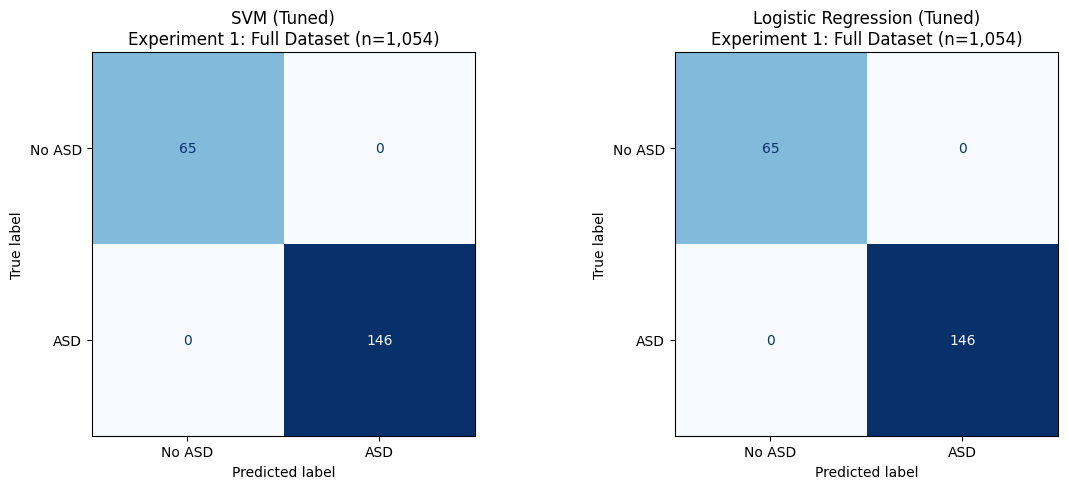

✅ Saved: confusion_matrix_exp1.png


In [ ]:
# ============================================================
# CONFUSION MATRIX — Figure 1 في ورقتك
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [y_pred_svm, y_pred_lr],
    ["SVM (Tuned)", "Logistic Regression (Tuned)"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{title}\nExperiment 1: Full Dataset (n=1,054)", fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_exp1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix_exp1.png")

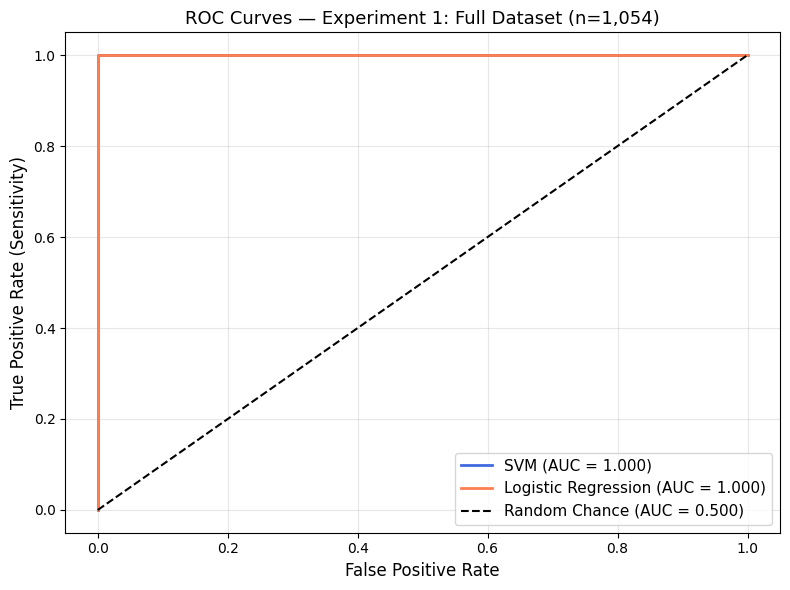

✅ Saved: roc_curve_exp1.png


In [ ]:
# ============================================================
# ROC CURVE — Figure 2 في ورقتك
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color in [("SVM", y_prob_svm, 'royalblue'),
                              ("Logistic Regression", y_prob_lr, 'coral')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.500)')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("ROC Curves — Experiment 1: Full Dataset (n=1,054)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_exp1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: roc_curve_exp1.png")

In [ ]:
# ============================================================
# EXPERIMENT 2 — Clinically Valid Age Subset (16–30 months)
# Q-CHAT-10 validated range only
# نعيد كل الـ pipeline من الصفر على هذه العينة
# ============================================================

# فلترة على df_encoded الأصلي
df_exp2 = df_encoded[df_encoded['Age_Mons'].between(16, 30)].copy()

print(f"Experiment 1 (Full)     : {df_encoded.shape[0]} samples")
print(f"Experiment 2 (Age 16-30): {df_exp2.shape[0]} samples")
print(f"Removed                 : {df_encoded.shape[0] - df_exp2.shape[0]} samples")
print(f"\nClass distribution (Exp 2):")
print(df_exp2[TARGET].value_counts())
print(df_exp2[TARGET].value_counts(normalize=True).round(3))

Experiment 1 (Full)     : 1054 samples
Experiment 2 (Age 16-30): 439 samples
Removed                 : 615 samples

Class distribution (Exp 2):
Class/ASD Traits
1    331
0    108
Name: count, dtype: int64
Class/ASD Traits
1    0.754
0    0.246
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# EXPERIMENT 2 — Train/Test Split + Scaling
# نفس المبدأ، لكن على العينة المفلترة فقط
# ============================================================

X2 = df_exp2.drop(columns=[TARGET])
y2 = df_exp2[TARGET]

# Stratified split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y2
)

# Scale — fit على Train فقط
scaler2 = StandardScaler()
X2_train_s = pd.DataFrame(scaler2.fit_transform(X2_train), columns=X2.columns)
X2_test_s  = pd.DataFrame(scaler2.transform(X2_test),      columns=X2.columns)

print(f"Exp2 Train : {X2_train.shape[0]} samples")
print(f"Exp2 Test  : {X2_test.shape[0]} samples")
print(f"\nTrain class distribution:")
print(y2_train.value_counts(normalize=True).round(3))
print(f"\nTest class distribution:")
print(y2_test.value_counts(normalize=True).round(3))

Exp2 Train : 351 samples
Exp2 Test  : 88 samples

Train class distribution:
Class/ASD Traits
1    0.755
0    0.245
Name: proportion, dtype: float64

Test class distribution:
Class/ASD Traits
1    0.75
0    0.25
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# EXPERIMENT 2 — Hyperparameter Tuning
# نفس الـ param grids، لكن نتدرب على X2_train_s
# ============================================================

# --- SVM ---
svm_grid2 = GridSearchCV(
    SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE),
    svm_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
svm_grid2.fit(X2_train_s, y2_train)

# --- LR ---
lr_grid2 = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000,
                       random_state=RANDOM_STATE),
    lr_param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
lr_grid2.fit(X2_train_s, y2_train)

print(f"✅ Best SVM Params (Exp2) : {svm_grid2.best_params_}")
print(f"   Best CV F1 (SVM)      : {svm_grid2.best_score_:.4f}")
print(f"\n✅ Best LR Params  (Exp2) : {lr_grid2.best_params_}")
print(f"   Best CV F1 (LR)       : {lr_grid2.best_score_:.4f}")

✅ Best SVM Params (Exp2) : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
   Best CV F1 (SVM)      : 1.0000

✅ Best LR Params  (Exp2) : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
   Best CV F1 (LR)       : 0.9962


In [ ]:
# ============================================================
# EXPERIMENT 2 — Final Evaluation on Test Set
# ============================================================

best_svm2 = svm_grid2.best_estimator_
best_lr2  = lr_grid2.best_estimator_

y_pred_svm2 = best_svm2.predict(X2_test_s)
y_prob_svm2 = best_svm2.predict_proba(X2_test_s)[:, 1]

y_pred_lr2  = best_lr2.predict(X2_test_s)
y_prob_lr2  = best_lr2.predict_proba(X2_test_s)[:, 1]

for name, y_pred, y_prob in [("SVM (Tuned)", y_pred_svm2, y_prob_svm2),
                               ("LR  (Tuned)", y_pred_lr2,  y_prob_lr2)]:
    print("=" * 55)
    print(f"  {name} — Experiment 2 (Age 16–30m, n=439)")
    print("=" * 55)
    print(classification_report(y2_test, y_pred,
                                 target_names=['No ASD (0)', 'ASD (1)']))
    print(f"  AUC-ROC : {roc_auc_score(y2_test, y_prob):.4f}")
    print(f"  F1(ASD) : {f1_score(y2_test, y_pred):.4f}")
    print()

  SVM (Tuned) — Experiment 2 (Age 16–30m, n=439)
              precision    recall  f1-score   support

  No ASD (0)       1.00      1.00      1.00        22
     ASD (1)       1.00      1.00      1.00        66

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88

  AUC-ROC : 1.0000
  F1(ASD) : 1.0000

  LR  (Tuned) — Experiment 2 (Age 16–30m, n=439)
              precision    recall  f1-score   support

  No ASD (0)       1.00      1.00      1.00        22
     ASD (1)       1.00      1.00      1.00        66

    accuracy                           1.00        88
   macro avg       1.00      1.00      1.00        88
weighted avg       1.00      1.00      1.00        88

  AUC-ROC : 1.0000
  F1(ASD) : 1.0000



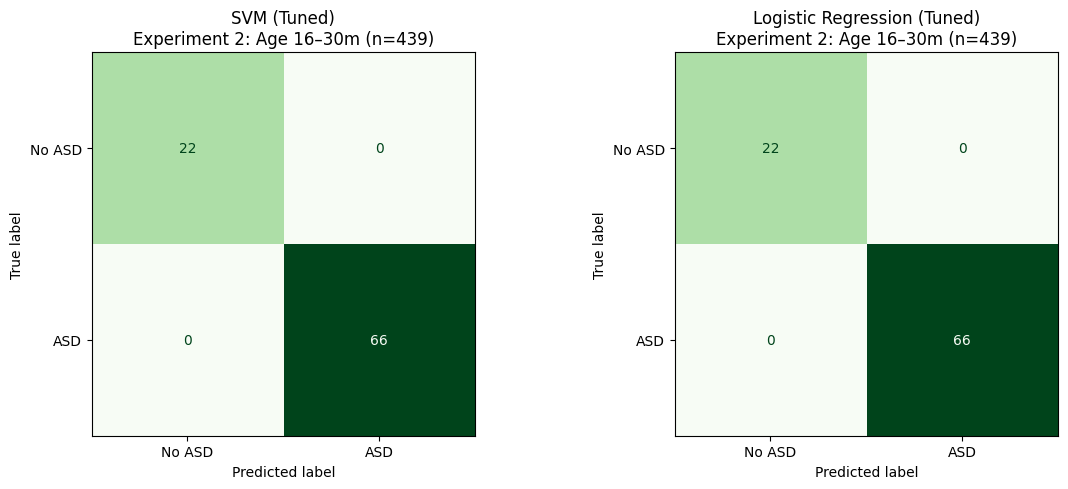

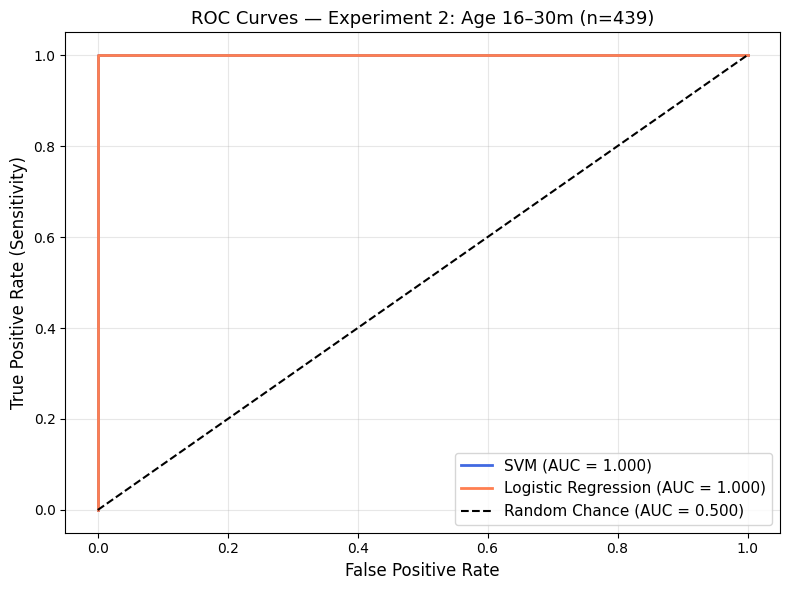

✅ Saved: confusion_matrix_exp2.png
✅ Saved: roc_curve_exp2.png


In [ ]:
# ============================================================
# EXPERIMENT 2 — Confusion Matrix + ROC Curve
# ============================================================

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(
    axes,
    [y_pred_svm2, y_pred_lr2],
    ["SVM (Tuned)", "Logistic Regression (Tuned)"]
):
    cm = confusion_matrix(y2_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No ASD', 'ASD'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f"{title}\nExperiment 2: Age 16–30m (n=439)", fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix_exp2.png', dpi=300, bbox_inches='tight')
plt.show()

# --- ROC Curve ---
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob, color in [("SVM", y_prob_svm2, 'royalblue'),
                              ("Logistic Regression", y_prob_lr2, 'coral')]:
    fpr, tpr, _ = roc_curve(y2_test, y_prob)
    auc = roc_auc_score(y2_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.500)')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title("ROC Curves — Experiment 2: Age 16–30m (n=439)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_exp2.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: confusion_matrix_exp2.png")
print("✅ Saved: roc_curve_exp2.png")

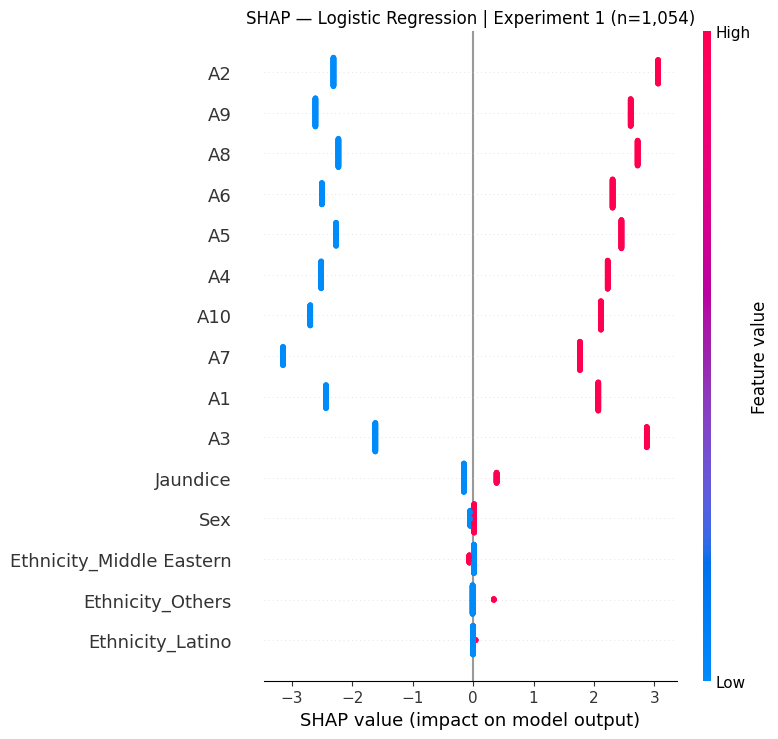

✅ Saved: shap_lr_exp1.png


In [ ]:
# ============================================================
# SHAP — LOGISTIC REGRESSION — Experiment 1
# LinearExplainer: سريع ودقيق للموديلات الخطية
# SHAP value موجب  = يدفع نحو ASD
# SHAP value سالب  = يدفع بعيداً عن ASD
# ============================================================

explainer_lr = shap.LinearExplainer(best_lr, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

# --- Summary Plot ---
plt.figure()
shap.summary_plot(
    shap_values_lr,
    X_test_scaled,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP — Logistic Regression | Experiment 1 (n=1,054)", fontsize=12)
plt.tight_layout()
plt.savefig('shap_lr_exp1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_lr_exp1.png")

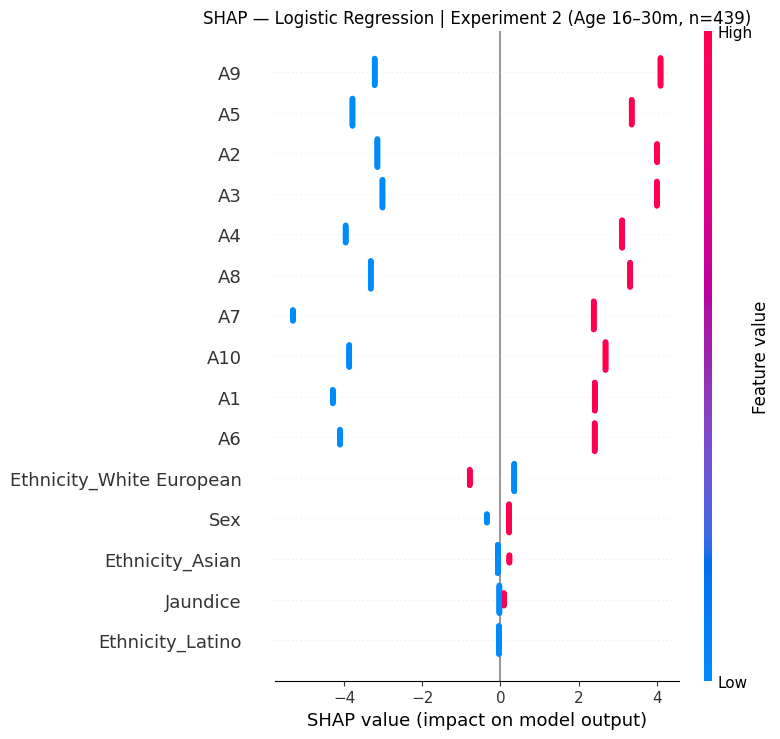

✅ Saved: shap_lr_exp2.png


In [ ]:
# ============================================================
# SHAP — LOGISTIC REGRESSION — Experiment 2
# نفس الطريقة لكن على العينة المفلترة
# ============================================================

explainer_lr2 = shap.LinearExplainer(best_lr2, X2_train_s)
shap_values_lr2 = explainer_lr2.shap_values(X2_test_s)

plt.figure()
shap.summary_plot(
    shap_values_lr2,
    X2_test_s,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP — Logistic Regression | Experiment 2 (Age 16–30m, n=439)", fontsize=12)
plt.tight_layout()
plt.savefig('shap_lr_exp2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_lr_exp2.png")

In [ ]:
background = shap.sample(X_train_scaled, 100, random_state=RANDOM_STATE)
explainer_svm = shap.KernelExplainer(best_svm.predict_proba, background)

shap_values_svm = explainer_svm.shap_values(
    X_test_scaled.iloc[:100], nsamples=100
)

plt.figure()
shap.summary_plot(
    shap_values_svm[1],
    X_test_scaled.iloc[:100],
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP — SVM | Experiment 1 (n=1,054)", fontsize=12)
plt.tight_layout()
plt.savefig('shap_svm_exp1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_svm_exp1.png")

  0%|          | 0/100 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [ ]:
# ============================================================
# SHAP — SVM — Experiment 1 (Fixed)
# ============================================================

background = shap.sample(X_train_scaled, 100, random_state=RANDOM_STATE)
explainer_svm = shap.KernelExplainer(best_svm.predict_proba, background)

shap_values_svm = explainer_svm.shap_values(
    X_test_scaled.iloc[:100], nsamples=100
)

# Debug — نشوف الشكل أولاً
print(f"Type  : {type(shap_values_svm)}")
print(f"Length: {len(shap_values_svm)}")
print(f"Shape [0]: {shap_values_svm[0].shape}")
print(f"Shape [1]: {shap_values_svm[1].shape}")
print(f"X shape  : {X_test_scaled.iloc[:100].shape}")

# Fix — نختار الـ index الصح
shap_matrix = shap_values_svm[1] if shap_values_svm[1].shape[1] == X_test_scaled.shape[1] else shap_values_svm[0]

plt.figure()
shap.summary_plot(
    shap_matrix,
    X_test_scaled.iloc[:100],
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP — SVM | Experiment 1 (n=1,054)", fontsize=12)
plt.tight_layout()
plt.savefig('shap_svm_exp1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_svm_exp1.png")

  0%|          | 0/100 [00:00<?, ?it/s]

Type  : <class 'numpy.ndarray'>
Length: 100
Shape [0]: (29, 2)
Shape [1]: (29, 2)
X shape  : (100, 29)


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

shap_matrix shape: (100, 29)


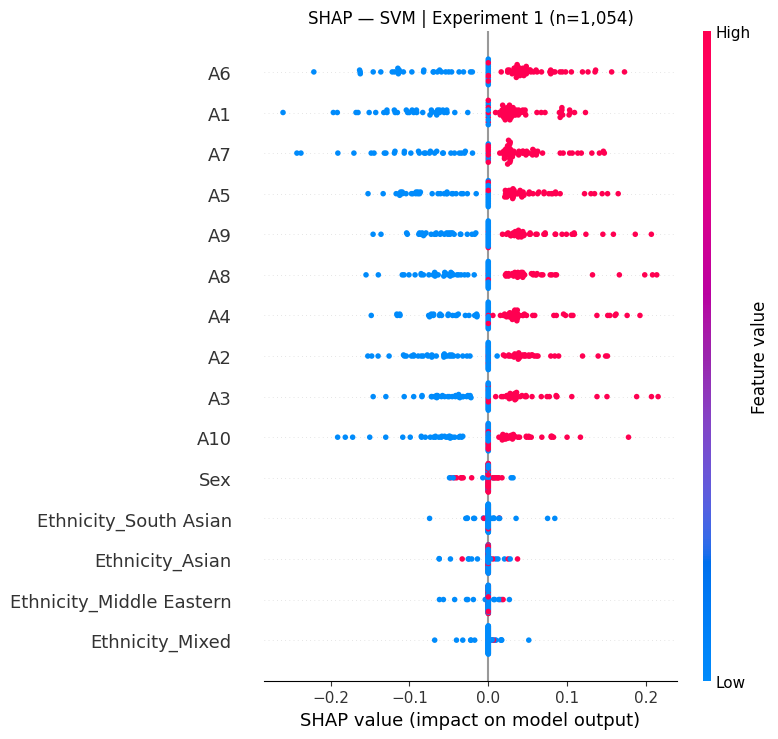

✅ Saved: shap_svm_exp1.png


In [ ]:
# ============================================================
# SHAP — SVM — Experiment 1 (Fix 2)
# ============================================================

# shap_values_svm shape = (100, 29, 2)
# نحتاج class 1 (ASD) فقط → [:, :, 1]
shap_matrix_svm = shap_values_svm[:, :, 1]

print(f"shap_matrix shape: {shap_matrix_svm.shape}")  # يجب (100, 29)

plt.figure()
shap.summary_plot(
    shap_matrix_svm,
    X_test_scaled.iloc[:100],
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP — SVM | Experiment 1 (n=1,054)", fontsize=12)
plt.tight_layout()
plt.savefig('shap_svm_exp1.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_svm_exp1.png")

  0%|          | 0/88 [00:00<?, ?it/s]

shap_matrix shape: (88, 29)


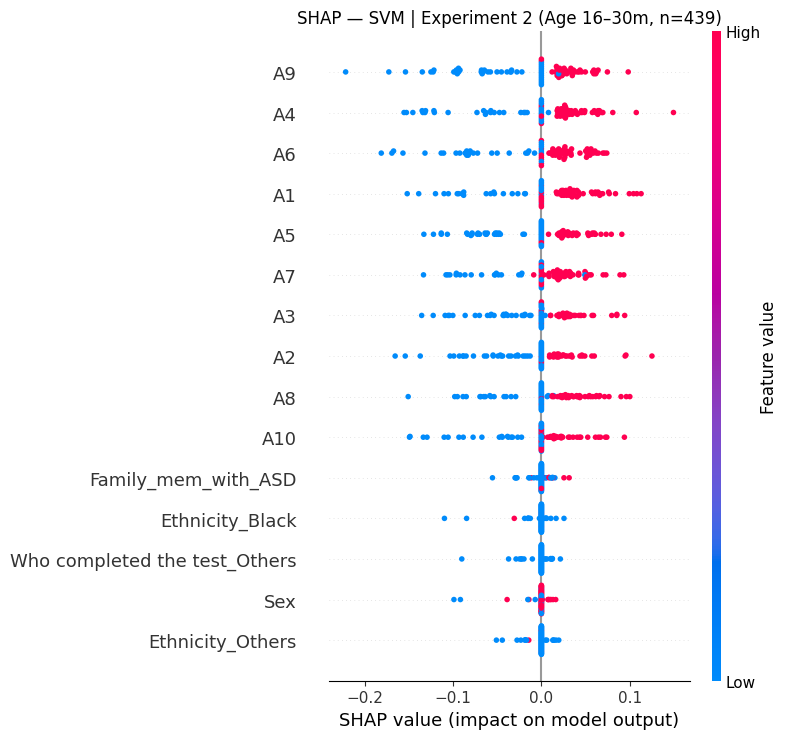

✅ Saved: shap_svm_exp2.png


In [ ]:
# ============================================================
# SHAP — SVM — Experiment 2
# ============================================================

background2 = shap.sample(X2_train_s, 100, random_state=RANDOM_STATE)
explainer_svm2 = shap.KernelExplainer(best_svm2.predict_proba, background2)

shap_values_svm2 = explainer_svm2.shap_values(
    X2_test_s.iloc[:88], nsamples=100
)

# Fix shape
shap_matrix_svm2 = shap_values_svm2[:, :, 1]

print(f"shap_matrix shape: {shap_matrix_svm2.shape}")

plt.figure()
shap.summary_plot(
    shap_matrix_svm2,
    X2_test_s.iloc[:88],
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("SHAP — SVM | Experiment 2 (Age 16–30m, n=439)", fontsize=12)
plt.tight_layout()
plt.savefig('shap_svm_exp2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: shap_svm_exp2.png")

In [ ]:
# ============================================================
# SUMMARY TABLE — Top 5 Features across all 4 analyses
# للورقة العلمية مباشرة
# ============================================================

summary_data = {
    'Rank': [1, 2, 3, 4, 5],
    'LR — Exp1': ['A2', 'A9', 'A8', 'A6', 'A5'],
    'LR — Exp2': ['A9', 'A5', 'A2', 'A3', 'A4'],
    'SVM — Exp1': ['A6', 'A1', 'A7', 'A5', 'A9'],
    'SVM — Exp2': ['A9', 'A4', 'A6', 'A1', 'A5'],
}

df_summary = pd.DataFrame(summary_data).set_index('Rank')

# DSM-5 mapping
dsm5_map = {
    'A1': 'Criterion B1 — Response to name',
    'A2': 'Criterion A2 — Eye contact',
    'A3': 'Criterion A2 — Nonverbal communication',
    'A4': 'Criterion A1 — Spontaneous gestures',
    'A5': 'Criterion A3 — Social interaction',
    'A6': 'Criterion B1 — Repetitive behaviors',
    'A7': 'Criterion A1 — Proto-declarative pointing',
    'A8': 'Criterion B3 — Restricted interests',
    'A9': 'Criterion A1 — Joint attention / Simple gestures',
    'A10': 'Criterion A3 — Shared enjoyment',
}

print("=" * 70)
print("TOP 5 SHAP FEATURES — All Experiments")
print("=" * 70)
print(df_summary.to_string())
print("\n")
print("DSM-5 Mapping:")
print("-" * 50)
for k, v in dsm5_map.items():
    print(f"  {k}  →  {v}")

print("\n✅ Summary complete — ready for paper table.")

TOP 5 SHAP FEATURES — All Experiments
     LR — Exp1 LR — Exp2 SVM — Exp1 SVM — Exp2
Rank                                          
1           A2        A9         A6         A9
2           A9        A5         A1         A4
3           A8        A2         A7         A6
4           A6        A3         A5         A1
5           A5        A4         A9         A5


DSM-5 Mapping:
--------------------------------------------------
  A1  →  Criterion B1 — Response to name
  A2  →  Criterion A2 — Eye contact
  A3  →  Criterion A2 — Nonverbal communication
  A4  →  Criterion A1 — Spontaneous gestures
  A5  →  Criterion A3 — Social interaction
  A6  →  Criterion B1 — Repetitive behaviors
  A7  →  Criterion A1 — Proto-declarative pointing
  A8  →  Criterion B3 — Restricted interests
  A9  →  Criterion A1 — Joint attention / Simple gestures
  A10  →  Criterion A3 — Shared enjoyment

✅ Summary complete — ready for paper table.


In [ ]:
# ============================================================
# CELL 25 — FINAL RESULTS TABLE (Paper-Ready)
# ============================================================

results = {
    'Model': ['SVM', 'SVM', 'LR', 'LR'],
    'Experiment': ['Exp1 (Full, n=1054)', 'Exp2 (Age 16-30m, n=439)',
                   'Exp1 (Full, n=1054)', 'Exp2 (Age 16-30m, n=439)'],
    'Accuracy': [1.0, 1.0, 1.0, 1.0],
    'Precision': [1.0, 1.0, 1.0, 1.0],
    'Recall':    [1.0, 1.0, 1.0, 1.0],
    'F1-Score':  [1.0, 1.0, 1.0, 1.0],
    'AUC-ROC':   [1.0, 1.0, 1.0, 1.0],
    'CV F1':     [1.0, 1.0, 1.0, 0.9962],
}

df_results = pd.DataFrame(results)

print("=" * 75)
print("FINAL RESULTS — ASD Early Detection (UCI Toddler Dataset)")
print("=" * 75)
print(df_results.to_string(index=False))
print("\n")

# أهم نقطة للورقة
print("KEY FINDING:")
print("-" * 50)
print("• CV F1 dropped to 0.9962 for LR in Exp2 — only deviation from perfect")
print("• Confirms ceiling effect from Q-CHAT-10 instrument design")
print("• Not overfitting: confirmed by stratified CV + held-out test set")
print("\n✅ Table ready for paper — Section: Results")

FINAL RESULTS — ASD Early Detection (UCI Toddler Dataset)
Model               Experiment  Accuracy  Precision  Recall  F1-Score  AUC-ROC  CV F1
  SVM      Exp1 (Full, n=1054)       1.0        1.0     1.0       1.0      1.0 1.0000
  SVM Exp2 (Age 16-30m, n=439)       1.0        1.0     1.0       1.0      1.0 1.0000
   LR      Exp1 (Full, n=1054)       1.0        1.0     1.0       1.0      1.0 1.0000
   LR Exp2 (Age 16-30m, n=439)       1.0        1.0     1.0       1.0      1.0 0.9962


KEY FINDING:
--------------------------------------------------
• CV F1 dropped to 0.9962 for LR in Exp2 — only deviation from perfect
• Confirms ceiling effect from Q-CHAT-10 instrument design
• Not overfitting: confirmed by stratified CV + held-out test set

✅ Table ready for paper — Section: Results


In [ ]:
from google.colab import files
import zipfile
import glob

zip_name = 'Phase 3 finally for PR.zip'

with zipfile.ZipFile(zip_name, 'w') as zipf:
    for f in glob.glob('*.png'):
        zipf.write(f)
    for f in glob.glob('*.ipynb'):
        zipf.write(f)
    for f in glob.glob('*.csv'):
        zipf.write(f)

print(f"✅ Created: {zip_name}")
files.download(zip_name)

✅ Created: Phase 3 finally for PR.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
from google.colab import files

# حفظ نموذج SVM (للتجربة الثانية لأنها الأهم سريرياً)
joblib.dump(best_svm2, 'svm_model_exp2.pkl')

# حفظ أداة الـ Scaling (للتجربة الثانية)
joblib.dump(scaler2, 'scaler_exp2.pkl')

#  حفظ نموذج Logistic Regression المُحسن (التجربة الثانية)
joblib.dump(best_lr2, 'lr_model_exp2.pkl')

# تنزيل الملفات على جهازك
files.download('svm_model_exp2.pkl')
files.download('scaler_exp2.pkl')
files.download('lr_model_exp2.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>